Step 1: Import required libraries

In [1]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
from skimage.segmentation import flood
from mpl_toolkits.mplot3d import Axes3D

Step 2: Download image from Google Drive

In [2]:
def gdrive_to_direct_url(share_url):
    file_id = share_url.split("/d/")[1].split("/")[0]
    return f"https://drive.google.com/uc?export=download&id={file_id}"

image_url = "https://drive.google.com/file/d/1PyyMD4vbN-y3NsFGqKzwHftDGq75tNYW/view?usp=sharing"
direct_url = gdrive_to_direct_url(image_url)

# Load image using OpenCV
resp = urllib.request.urlopen(direct_url)
image_np = np.asarray(bytearray(resp.read()), dtype="uint8")
image = cv2.imdecode(image_np, cv2.IMREAD_COLOR)

if image is None:
    raise ValueError("Image could not be loaded. Check the URL!")

Step 3: Preprocess Image

In [3]:
# Convert to grayscale for segmentation
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur to remove noise
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Normalize image
gray_norm = cv2.normalize(blurred.astype("float32"), None, 0.0, 1.0, cv2.NORM_MINMAX)

Definition: Region Growing

    # Region growing is a pixel-based image segmentation technique.

    # It starts from a seed pixel and adds neighboring pixels based on similarity (e.g., intensity).
    
        It's useful for extracting continuous regions like planes or textures.

Step 4: Region Growing Plane Segmentation

In [4]:
# Choose a seed point manually or automatically (here manually)
seed_point = (gray.shape[0]//2, gray.shape[1]//2)

# Define tolerance threshold for similarity
tolerance = 0.02

# Perform region growing
mask = flood(gray_norm, seed_point, tolerance=tolerance)

# Binary segmented output
segmented = np.zeros_like(gray_norm)
segmented[mask] = 1.0

Step 5: Color the Segmented Region

In [5]:
# Create a copy of the original image
colored_overlay = image.copy()

# Choose color (e.g., green): (B, G, R)
color = (0, 255, 0)

# Create boolean mask and apply color
for c in range(3):  # For B, G, R channels
    colored_overlay[:, :, c] = np.where(mask, color[c], image[:, :, c])

# Blend the overlay with original image for transparency
alpha = 0.5  # 0: original, 1: fully colored
blended = cv2.addWeighted(image, 1 - alpha, colored_overlay, alpha, 0)

# ---------------------------------------------
# 🧪

Step 6: Gradient Magnitude for Normals


    Importance: Highlights region edges or pseudo-normal structure
        # Sobel Derivatives:
        #   ∂I/∂x ≈ Sobel_x, ∂I/∂y ≈ Sobel_y
        #   Gradient Magnitude: sqrt((∂I/∂x)² + (∂I/∂y)²)

In [6]:
grad_x = cv2.Sobel(gray_norm, cv2.CV_64F, 1, 0, ksize=3)
grad_y = cv2.Sobel(gray_norm, cv2.CV_64F, 0, 1, ksize=3)
grad_mag = np.sqrt(grad_x**2 + grad_y**2)

Step 7: Visualize All Results

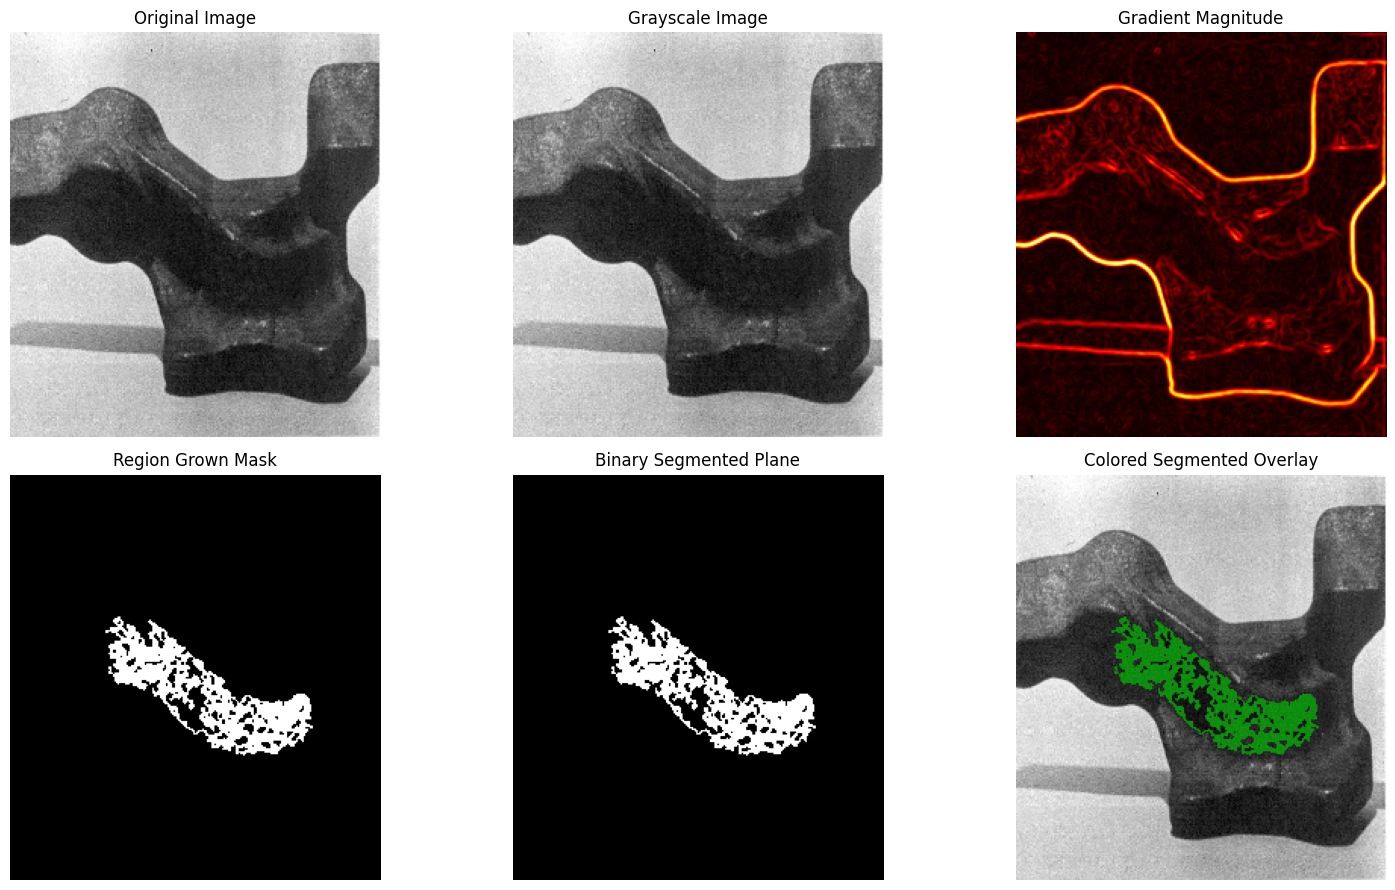

In [7]:
plt.figure(figsize=(16, 9))

plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(grad_mag, cmap='hot')
plt.title("Gradient Magnitude")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(mask, cmap='gray')
plt.title("Region Grown Mask")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(segmented, cmap='gray')
plt.title("Binary Segmented Plane")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB))
plt.title("Colored Segmented Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()